In [2]:
import numpy as np
import pandas as pd
train = pd.read_csv("../data/raw/train_FD003.txt", sep=r"\s+", header=None)
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583


In [3]:
train.describe()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
count,24720.000000,24720.000000,24720.000000,24720.000000,24720.0,24720.00,24720.000000,24720.000000,24720.000000,2.472000e+04,...,24720.000000,24720.000000,24720.000000,24720.000000,2.472000e+04,24720.000000,24720.0,24720.0,24720.000000,24720.000000
mean,48.631877,139.077063,-0.000024,0.000005,100.0,518.67,642.457858,1588.079175,1404.471212,1.462000e+01,...,523.050873,2388.071643,8144.202916,8.396176,3.000000e-02,392.566545,2388.0,100.0,38.988552,23.393024
std,29.348985,98.846675,0.002194,0.000294,0.0,0.00,0.523031,6.810418,9.773178,3.552786e-15,...,3.255314,0.158121,16.504118,0.060512,6.939034e-18,1.761459,0.0,0.0,0.248865,0.149234
min,1.000000,1.000000,-0.008600,-0.000600,100.0,518.67,640.840000,1564.300000,1377.060000,1.462000e+01,...,517.770000,2386.930000,8099.680000,8.156300,3.000000e-02,388.000000,2388.0,100.0,38.170000,22.872600
25%,23.000000,62.000000,-0.001500,-0.000200,100.0,518.67,642.080000,1583.280000,1397.187500,1.462000e+01,...,521.150000,2388.010000,8134.510000,8.360600,3.000000e-02,391.000000,2388.0,100.0,38.830000,23.296200
50%,47.000000,124.000000,-0.000000,-0.000000,100.0,518.67,642.400000,1587.520000,1402.910000,1.462000e+01,...,521.980000,2388.070000,8141.200000,8.398300,3.000000e-02,392.000000,2388.0,100.0,38.990000,23.391600
75%,74.000000,191.000000,0.001500,0.000300,100.0,518.67,642.790000,1592.412500,1410.600000,1.462000e+01,...,523.840000,2388.140000,8149.230000,8.437000,3.000000e-02,394.000000,2388.0,100.0,39.140000,23.483300
max,100.000000,525.000000,0.008600,0.000700,100.0,518.67,645.110000,1615.390000,1441.160000,1.462000e+01,...,537.400000,2388.610000,8290.550000,8.570500,3.000000e-02,399.000000,2388.0,100.0,39.850000,23.950500


In [4]:
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]
train.columns = columns
train.head(5)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583


In [5]:
train.nunique()

engine_id     100
cycle         525
setting_1     160
setting_2      14
setting_3       1
sensor_1        1
sensor_2      334
sensor_3     3358
sensor_4     4383
sensor_5        1
sensor_6       17
sensor_7     1854
sensor_8      161
sensor_9     7114
sensor_10       4
sensor_11     170
sensor_12    1772
sensor_13     163
sensor_14    6320
sensor_15    3122
sensor_16       1
sensor_17      12
sensor_18       1
sensor_19       1
sensor_20     165
sensor_21    6440
dtype: int64

setting 3 senor 1,5,16,18,19 dosent really help as they only have 1 unique value

In [7]:
usefull_sensors = ['setting_1', 'setting_2', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

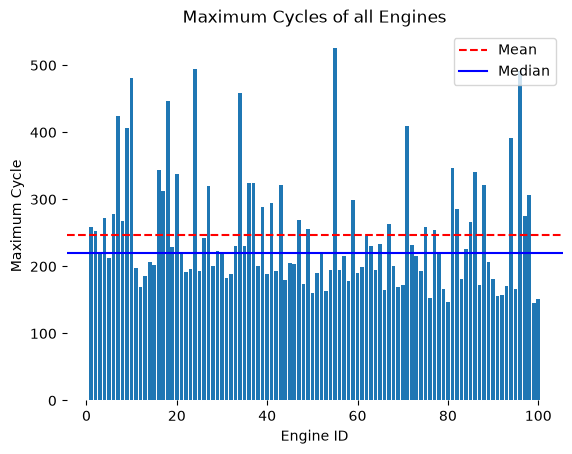

In [8]:
import matplotlib.pyplot as plt
max_cycles = train.groupby("engine_id")["cycle"].max()
plt.bar(max_cycles.index, max_cycles.values)
plt.xlabel("Engine ID")
plt.ylabel("Maximum Cycle")
plt.title("Maximum Cycles of all Engines")
plt.axhline(y=max_cycles.mean(), color="r", linestyle="--", label="Mean")
plt.axhline(y=max_cycles.median(), color="b", linestyle="-", label="Median")
legend = plt.legend()
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

In [9]:
train["rul"] = train["engine_id"].map(max_cycles) - train["cycle"]

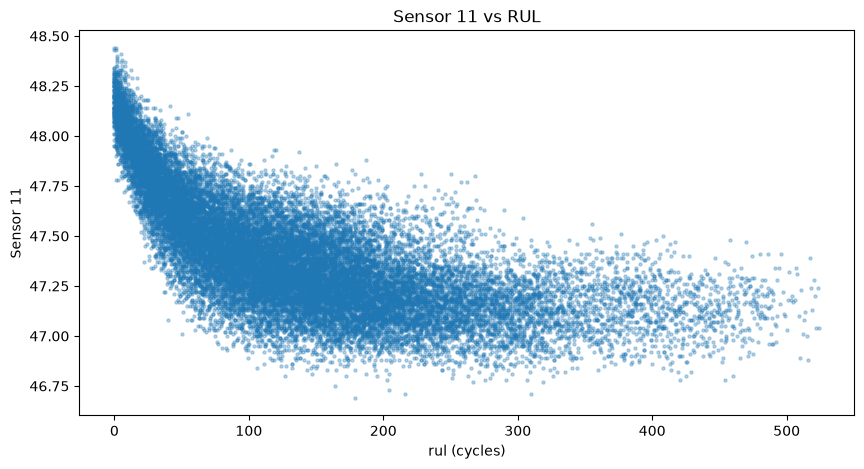

In [10]:
plt.figure(figsize=(10, 5))
plt.scatter(
    train["rul"],
    train["sensor_11"],
    s=5,
    alpha=0.3
)
plt.xlabel("rul (cycles)")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 vs RUL")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
engine_ids = train["engine_id"].unique()
train_engines, val_engines = train_test_split(engine_ids, test_size=0.2, random_state=42)
print("Training Engines:",len(train_engines))
print("Validation Engines:",len(val_engines))

Training Engines: 80
Validation Engines: 20


In [12]:
train_data = train[train["engine_id"].isin(train_engines)].copy()
val_data = train[train["engine_id"].isin(val_engines)].copy()
print("traing rows: ",len(train_data))
print("validation rows: ",len(val_data))

traing rows:  20012
validation rows:  4708


In [13]:
feature_col = usefull_sensors
X_train = train_data[feature_col]
Y_train = train_data["rul"]

X_val = val_data[feature_col]
Y_val = val_data["rul"]

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))

baseline MAE:  37.49695624468988
baseline RMSE:  57.2114946168287


this was our base model with high error we will try to decrease it as much as possible

<Axes: >

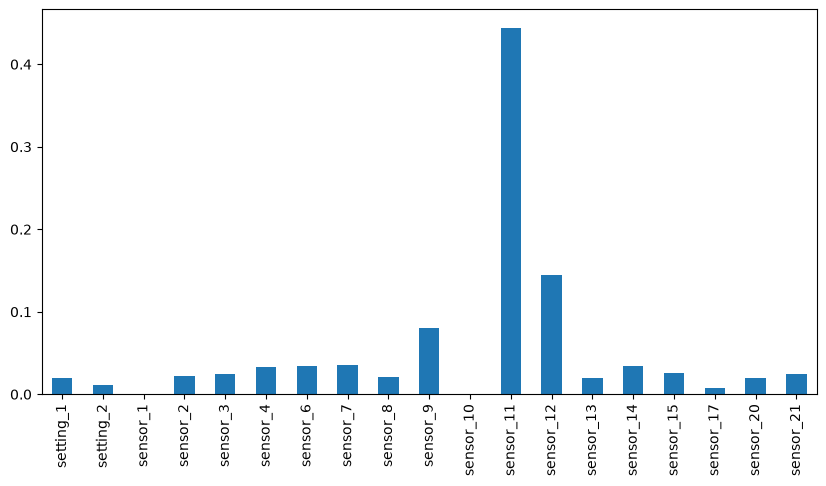

In [15]:
feature_importance = pd.Series(baseline_model.feature_importances_, index=feature_col)#.sort_values(ascending=False)
feature_importance.plot(kind="bar", figsize=(10, 5))

lets try the model after droping senor 1 and 10

In [16]:
usefull_sensors2 = ['setting_1', 'setting_2',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

In [17]:
train_data2 = train[train["engine_id"].isin(train_engines)].copy()
val_data2 = train[train["engine_id"].isin(val_engines)].copy()
print("traing rows: ",len(train_data))
print("validation rows: ",len(val_data))

traing rows:  20012
validation rows:  4708


In [18]:
engine_ids = train["engine_id"].unique()
train_engines2, val_engines2 = train_test_split(engine_ids, test_size=0.2, random_state=42)
feature_col2 = usefull_sensors2
X_train2 = train_data[feature_col2]
Y_train2 = train_data["rul"]

X_val2 = val_data2[feature_col2]
Y_val2 = val_data2["rul"]

In [19]:
baseline_model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model2.fit(X_train2, Y_train2)
y_pred2 = baseline_model2.predict(X_val2)
print("baseline MAE: ", mean_absolute_error(Y_val2, y_pred2))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val2, y_pred2)))

baseline MAE:  37.54519116397621
baseline RMSE:  57.22891365261936


removing sensor 1 and 10 dose not help but it made thing worse so we will keep it

In [20]:
from sklearn.inspection import permutation_importance
prem_importance = permutation_importance(baseline_model, X_val, Y_val, n_repeats=15, random_state=42, n_jobs=-1, scoring="neg_mean_absolute_error")
prem_importance_df = pd.DataFrame({
    "sensor": feature_col,
    "importance": prem_importance.importances_mean,
    "importance_std": prem_importance.importances_std
})
prem_importance_df

,sensor,importance,importance_std
0,setting_1,0.005756,0.037350
1,setting_2,0.029755,0.033638
2,sensor_1,0.000000,0.000000
3,sensor_2,0.508849,0.055141
4,sensor_3,0.547823,0.099636
5,sensor_4,1.541491,0.097620
6,sensor_6,3.084024,0.247613
7,sensor_7,0.477007,0.160354
8,sensor_8,1.027616,0.076471
9,sensor_9,8.209258,0.266126


so it shows that sensor 1 importance is 0 so we will drop it

In [21]:
usefull_sensors.remove("sensor_1")

In [22]:
train_rolling = train.copy()

In [23]:
window = 20
for col in usefull_sensors:
    train_rolling[f"{col}_rmean"]=(train_rolling.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).mean()))
    train_rolling[f"{col}_rstd"]=(train_rolling.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0)))

In [24]:
train_rolling.columns

Index(['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'rul',
       'setting_1_rmean', 'setting_1_rstd', 'setting_2_rmean',
       'setting_2_rstd', 'sensor_2_rmean', 'sensor_2_rstd', 'sensor_3_rmean',
       'sensor_3_rstd', 'sensor_4_rmean', 'sensor_4_rstd', 'sensor_6_rmean',
       'sensor_6_rstd', 'sensor_7_rmean', 'sensor_7_rstd', 'sensor_8_rmean',
       'sensor_8_rstd', 'sensor_9_rmean', 'sensor_9_rstd', 'sensor_10_rmean',
       'sensor_10_rstd', 'sensor_11_rmean', 'sensor_11_rstd',
       'sensor_12_rmean', 'sensor_12_rstd', 'sensor_13_rmean',
       'sensor_13_rstd', 'sensor_14_rmean', 'sensor_14_rstd',
       'sensor_15_rmean', 'sensor_15_rstd', 'sensor_17_rmean',
       'se

In [25]:
usefull_sensors3 = ['setting_1', 'setting_2','sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'setting_1_rmean', 'setting_1_rstd', 'setting_2_rmean',
       'setting_2_rstd', 'sensor_2_rmean', 'sensor_2_rstd', 'sensor_4_rmean', 'sensor_4_rstd', 'sensor_6_rmean',
       'sensor_6_rstd', 'sensor_7_rmean', 'sensor_7_rstd', 'sensor_8_rmean',
       'sensor_8_rstd', 'sensor_9_rmean', 'sensor_9_rstd', 'sensor_10_rmean',
       'sensor_10_rstd', 'sensor_11_rmean', 'sensor_11_rstd',
       'sensor_12_rmean', 'sensor_12_rstd', 'sensor_13_rmean',
       'sensor_13_rstd', 'sensor_14_rmean', 'sensor_14_rstd',
       'sensor_15_rmean', 'sensor_15_rstd', 'sensor_17_rmean',
       'sensor_17_rstd', 'sensor_20_rmean', 'sensor_20_rstd',
       'sensor_21_rmean', 'sensor_21_rstd']

In [26]:
engine_ids3 = train_rolling["engine_id"].unique()
train_engines3, val_engines3 = train_test_split(engine_ids3, test_size=0.2, random_state=42)
train_data3 = train_rolling[train_rolling["engine_id"].isin(train_engines3)].copy()
val_data3 = train_rolling[train_rolling["engine_id"].isin(val_engines3)].copy()

feature_col3 = usefull_sensors3
X_train3 = train_data3[feature_col3]
Y_train3 = train_data3["rul"]
X_val3 = val_data3[feature_col3]
Y_val3 = val_data3["rul"]

In [27]:
baseline_model3 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model3.fit(X_train3, Y_train3)
y_pred3 = baseline_model3.predict(X_val3)
print("baseline MAE: ", mean_absolute_error(Y_val3, y_pred3))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val3, y_pred3)))

baseline MAE:  37.35364485981308
baseline RMSE:  55.80846101571944


rolling feature didnt helped much, now we will try to capp the values

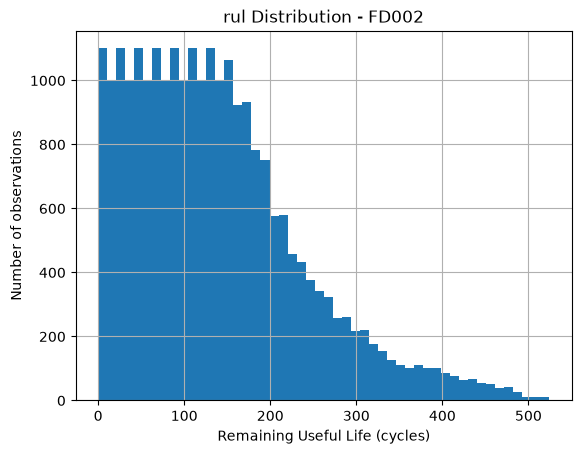

In [28]:
train["rul"].hist(bins=50)
plt.xlabel("Remaining Useful Life (cycles)")
plt.ylabel("Number of observations")
plt.title("rul Distribution - FD002")
plt.show()

In [29]:
(train["rul"] > 130).sum()

np.int64(11620)

In [30]:
train["RUL_capped"] = train["rul"].clip(upper=130)

train[["rul", "RUL_capped"]].head()

,rul,RUL_capped
0,258,130
1,257,130
2,256,130
3,255,130
4,254,130


In [31]:
train_data = train[train["engine_id"].isin(train_engines)].copy()
val_data = train[train["engine_id"].isin(val_engines)].copy()
feature_col = usefull_sensors
X_train = train_data[feature_col]
Y_train = train_data["RUL_capped"]
X_val = val_data[feature_col]
Y_val = val_data["RUL_capped"]

In [32]:
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))

baseline MAE:  11.939541206457095
baseline RMSE:  17.18675739324139


so after using rul capped this error decreased now we will try to use rolling features


In [33]:
train_rolling["RUL_capped"] = train_rolling["rul"].clip(upper=130)

train_rolling[["rul", "RUL_capped"]].head()

,rul,RUL_capped
0,258,130
1,257,130
2,256,130
3,255,130
4,254,130


In [34]:
engine_ids3 = train_rolling["engine_id"].unique()
train_engines3, val_engines3 = train_test_split(engine_ids3, test_size=0.2, random_state=42)
train_data3 = train_rolling[train_rolling["engine_id"].isin(train_engines3)].copy()
val_data3 = train_rolling[train_rolling["engine_id"].isin(val_engines3)].copy()

feature_col3 = usefull_sensors3
X_train3 = train_data3[feature_col3]
Y_train3 = train_data3["RUL_capped"]
X_val3 = val_data3[feature_col3]
Y_val3 = val_data3["RUL_capped"]

In [35]:
baseline_model3 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model3.fit(X_train3, Y_train3)
y_pred3 = baseline_model3.predict(X_val3)
print("baseline MAE: ", mean_absolute_error(Y_val3, y_pred3))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val3, y_pred3)))

baseline MAE:  11.528128717077315
baseline RMSE:  17.227280558268767


capping the rul value and using the rolling features does not have much effect so we will not consider this as its complexity is higher then the normal capped

lets try different models

In [36]:
from xgboost import XGBRegressor
import numpy as np

modelx = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
modelx.fit(X_train, Y_train)

# Predict
predictions = modelx.predict(X_val)

# Calculate errors
mae = mean_absolute_error(Y_val, predictions)
rmse = np.sqrt(mean_squared_error(Y_val, predictions))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 11.580068588256836
RMSE: 17.024193994205532


In [37]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

modell = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

# Train
modell.fit(
    X_train, Y_train,
    eval_set=[(X_val, Y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=30)]
)

# Predict
predictions = modell.predict(X_val)

# Calculate errors
mae = mean_absolute_error(Y_val, predictions)
rmse = np.sqrt(mean_squared_error(Y_val, predictions))

print("MAE :", mae)
print("RMSE:", rmse)


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[127]	valid_0's l1: 11.4144	valid_0's l2: 280.171
MAE : 11.41441920930353
RMSE: 16.738322889699276


e:\software\predictive-maintenance\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


the best model we got was using lgbm with 
MAE : 11.41441920930353
RMSE: 16.738322889699276

lets move towards testing

In [38]:
test = pd.read_csv("../data/raw/test_FD003.txt", sep=r"\s+", header=None)

In [39]:
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]
test.columns = columns

In [40]:
test_last = (
    test.sort_values(["engine_id", "cycle"])
        .groupby("engine_id")
        .tail(1)
        .sort_values("engine_id")
        .reset_index(drop=True)
)

In [41]:
X_test = test_last[usefull_sensors]
y_true = pd.read_csv("../data/raw/RUL_FD003.txt", header=None).squeeze()
y_true = y_true.clip(upper=130)

y_pred = modell.predict(X_test)  

print("test MAE: ", mean_absolute_error(y_true, y_pred))
print("test RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))

test MAE:  15.99164973528535
test RMSE:  21.743515924212197


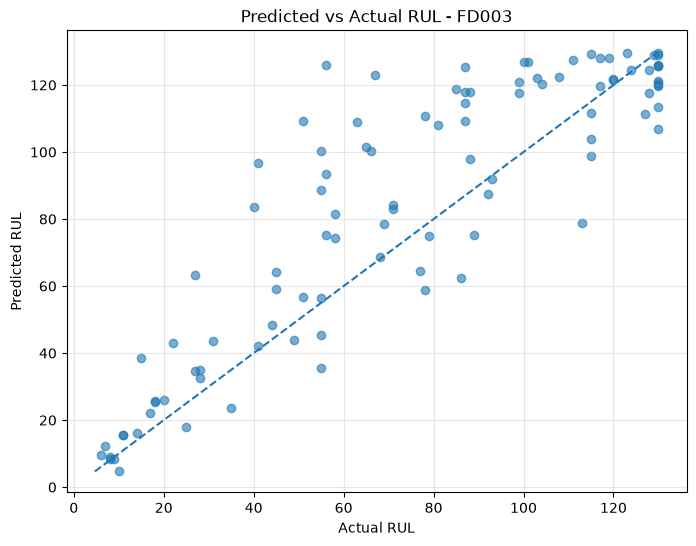

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(y_true, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual RUL - FD003")

plt.grid(True, alpha=0.3)
plt.show()